In [1]:
import numpy as np
import qutip
import pylab as plt
from tools.hamiltonian import build_JC_hamiltonian, eigenvec, E_list, build_decoupling_matrix
from tools.drive_envelope import build_drive_envelope
from pathlib import Path
import time

### Build Hamiltonian

In [61]:
H = build_JC_hamiltonian()
cdim_0 = H.dims[0][0]
qdim_0 =  H.dims[0][1] # assumed to be 2

# Qubit T1 and T2
T1 = np.inf#10000
T2 = 3_200 #2100
Tphi = 1 / (1 / T2 - 0.5 / T1) #np.inf
cavT1 = 500_000 #500k

### Define operators

In [62]:
# Cavity operators
a  = qutip.tensor(qutip.destroy(cdim_0), qutip.qeye(qdim_0))  
ad = a.dag()   

# Qubit operators (2-dimensional Hilbert space)
sp = qutip.tensor(qutip.qeye(cdim_0), qutip.sigmap())     # Pauli +
sm = qutip.tensor(qutip.qeye(cdim_0), qutip.sigmam())     # Pauli -
sx = qutip.tensor(qutip.qeye(cdim_0), qutip.sigmax())     # Pauli X
sz = qutip.tensor(qutip.qeye(cdim_0), qutip.sigmaz())     # Pauli Z

# Drive sequence
state_name = "0p3"
s_0to1p = 68 # Gaussian pulse sigma
s_1pto2m = 48
s_2mto3p = 44
drive_0to1p_params = (0.00442545*0.5/2, E_list[2] - E_list[0], 0, s_0to1p) # amp, freq, start time, sigma
drive_1pto2m_params = (0.00888164/2, E_list[3] - E_list[2], s_0to1p * 4, s_1pto2m)
drive_2mto3p_params = (0.00954657/2, E_list[6] - E_list[3], (s_0to1p + s_1pto2m) * 4, s_2mto3p)
t_max = (s_0to1p + s_1pto2m + s_2mto3p)*4

# Build projector list
eigenvec_list = [qutip.tensor(qutip.basis(cdim_0, 0), qutip.basis(2, 0))]
eigenvec_list += [eigenvec(ii, 2*jj-1) for ii in range(1, 6) for jj in range(2)] # 0, 1-, 1+, 2-, 2+,...
proj_list = [qutip.ket2dm(evec) for evec in eigenvec_list]

# Build jump operators
c_T1 = np.sqrt(1/T1)*sp
c_Tphi = np.sqrt((1/Tphi) / 2.0) * -sz
c_cavT1 = np.sqrt(1/cavT1)*a
c_ops = [c_T1, c_Tphi, c_cavT1]

### Time-dependent Hamiltonian

In [7]:
# Full time-dependent Hamiltonian
Hcoeff1, Hcoeff1_conj = build_drive_envelope(*drive_0to1p_params)
Hcoeff2, Hcoeff2_conj  = build_drive_envelope(*drive_1pto2m_params)
Hcoeff3, Hcoeff3_conj  = build_drive_envelope(*drive_2mto3p_params)
Hd1 = sm # rising operator (not a typo)
Hd2 = sp # lowering operator (not a typo)
H_td = [H, 
        [Hd1, Hcoeff1], 
        [Hd2, Hcoeff1_conj], 
        [Hd1, Hcoeff2], 
        [Hd2, Hcoeff2_conj], 
        [Hd1, Hcoeff3], 
        [Hd2, Hcoeff3_conj], ]

### Solve ME

#### Initial way

In [ ]:
psi0 = qutip.tensor(qutip.basis(cdim_0, 0), qutip.basis(qdim_0, 0))
tlist = np.linspace(0.0, t_max, 1_001)
result = qutip.mesolve(H_td, psi0, tlist, c_ops, 
                    proj_list,
                    options = qutip.Options(store_states=True))

/Users/dorogov/env/lib/python3.10/site-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(
/Users/dorogov/env/lib/python3.10/site-packages/qutip/solver/solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


#### Ramp decay

In [63]:
ramp_duration = 200
psi0 = qutip.tensor(qutip.basis(cdim_0, 0), qutip.basis(qdim_0, 0))
tlist_with_ramp = np.linspace(0.0, t_max+ramp_duration, 1_501)
result_ramp = qutip.mesolve(H_td, psi0, tlist_with_ramp, c_ops, 
                    proj_list,
                    options = qutip.Options(store_states=True))

### Project on the detuned eigenstate

In [ ]:
ADM = build_decoupling_matrix() # project the JC resonant state on the corresponding adiabatically detuned state
rho_JC_final = result.states[-1]# qutip.ket2dm(psi_JC_final)
rho_dec_final = ADM * rho_JC_final * ADM.dag()
rho_cav_final = rho_dec_final.ptrace(0)

In [64]:
rho_JC_final_ramp = result_ramp.states[-1]# qutip.ket2dm(psi_JC_final)
rho_dec_final_ramp = ADM * rho_JC_final_ramp * ADM.dag()
rho_cav_final_ramp = rho_dec_final_ramp.ptrace(0)

### Plot evolution

In [16]:
label_list = np.array(["0", "1-", "1+", "2-", "2+", "3-", "3+", "4-", "4+", "5-", "5+"])

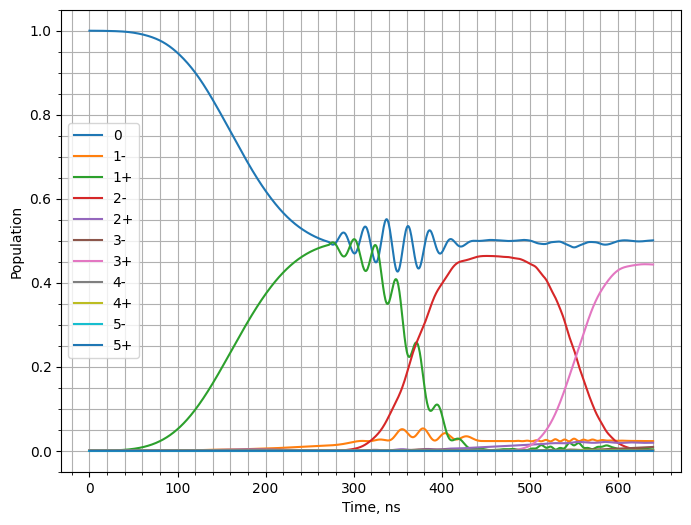

In [29]:
## Print state evolution
fig = plt.figure(figsize=(8, 6))
ax = plt.gca()
for ii in range(len(proj_list)):
    ax.plot(tlist, result.expect[ii], label = label_list[ii])
ax.legend()
ax.minorticks_on()
ax.grid(which="both")
ax.set(xlabel="Time, ns", ylabel="Population")
fig.savefig("figures_May_2026/Evolution_initial.jpg", bbox_inches="tight", dpi=400)

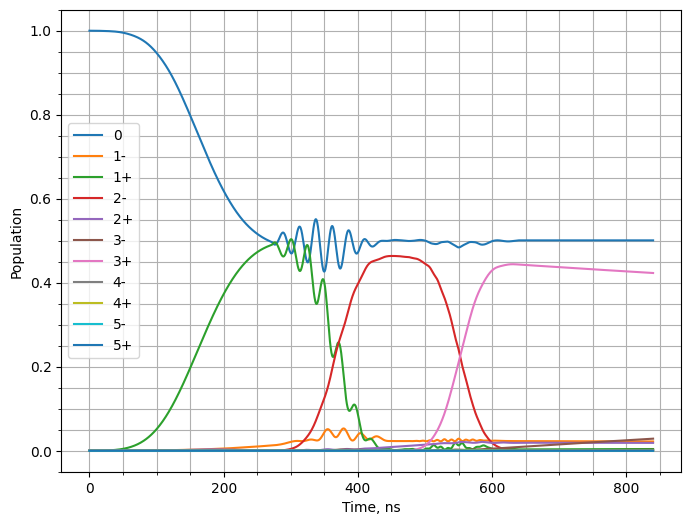

In [34]:
## Print state evolution
fig = plt.figure(figsize=(8, 6))
ax = plt.gca()
for ii in range(len(proj_list)):
    ax.plot(tlist_with_ramp, result_ramp.expect[ii], label = label_list[ii])
ax.legend()
ax.minorticks_on()
ax.grid(which="both")
ax.set(xlabel="Time, ns", ylabel="Population")
fig.savefig("figures_May_2026/Evolution_ramp.jpg", bbox_inches="tight", dpi=400)

### Compute fidelity

In [23]:
p_off = qutip.basis(cdim_0, 3)*qutip.basis(cdim_0, 0).dag() # Upper diagonal
phase = np.angle((rho_cav_final*p_off).tr())
psi_target = (qutip.basis(cdim_0, 0) + np.exp(-1j*phase)*qutip.basis(cdim_0, 3)).unit()
rho_target = qutip.ket2dm(psi_target)
print("Cavity fidelity: ", qutip.fidelity(rho_target, rho_cav_final)**2)
rho_cav_final

Cavity fidelity:  0.9273066821110457


Quantum object: dims=[[6], [6]], shape=(6, 6), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 5.23763469e-01-6.83858604e-17j -1.40612141e-02+1.23499797e-02j
   6.76103144e-03+1.11223166e-02j -4.42115740e-01-3.79093001e-02j
   2.96920612e-04+4.31723051e-03j  1.17676219e-05-5.51489047e-06j]
 [-1.40612141e-02-1.23499797e-02j  4.25186999e-03+6.07419847e-17j
   1.08761448e-04+4.40859937e-04j  1.11030960e-02+1.22937883e-02j
   2.95756427e-05-8.84982157e-05j -7.43182338e-07+1.11188776e-06j]
 [ 6.76103144e-03-1.11223166e-02j  1.08761448e-04-4.40859937e-04j
   2.80373161e-02+2.54728731e-18j -8.54221465e-03+1.01241000e-02j
   1.26115492e-04+1.07421108e-04j  8.31237182e-07+1.66789169e-07j]
 [-4.42115740e-01+3.79093001e-02j  1.11030960e-02-1.22937883e-02j
  -8.54221465e-03-1.01241000e-02j  4.43373828e-01+8.08579130e-18j
  -6.44058590e-04-4.25253386e-03j -1.08121429e-05+6.30623781e-06j]
 [ 2.96920612e-04-4.31723051e-03j  2.95756427e-05+8.84982157e-05j
   1.26115492e-04-1.07421108e-04j -6.4405

In [65]:
p_off = qutip.basis(cdim_0, 3)*qutip.basis(cdim_0, 0).dag() # Upper diagonal
phase_ramp = np.angle((rho_cav_final_ramp*p_off).tr())
psi_target_ramp = (qutip.basis(cdim_0, 0) + np.exp(-1j*phase_ramp)*qutip.basis(cdim_0, 3)).unit()
rho_target_ramp = qutip.ket2dm(psi_target_ramp)
print("Cavity fidelity with the ramp duration included: ", qutip.fidelity(rho_target_ramp, rho_cav_final_ramp)**2)
rho_cav_final_ramp

Cavity fidelity with the ramp duration included:  0.9287701218568776


Quantum object: dims=[[6], [6]], shape=(6, 6), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 5.14371820e-01-9.01500262e-18j  7.25655798e-03-1.64868667e-02j
  -2.35387548e-03-1.28650737e-02j  4.35781819e-01-1.01595537e-01j
  -4.04683782e-03+1.63001624e-03j -8.37307495e-06+1.00885778e-05j]
 [ 7.25655798e-03+1.64868667e-02j  3.69664054e-03+2.32403767e-17j
   2.78121503e-04-2.31862677e-05j  9.75956491e-03+1.37793648e-02j
  -9.56620938e-05-6.59909929e-05j -6.54094065e-07+6.84908732e-07j]
 [-2.35387548e-03+1.28650737e-02j  2.78121503e-04+2.31862677e-05j
   3.33028985e-02+1.54716517e-17j -6.62805056e-05+1.31956556e-02j
  -4.06344259e-06-1.54633917e-04j  3.78479496e-07-4.29041545e-07j]
 [ 4.35781819e-01+1.01595537e-01j  9.75956491e-03-1.37793648e-02j
  -6.62805056e-05-1.31956556e-02j  4.48232767e-01-2.47269630e-17j
  -4.30125355e-03+6.58650082e-04j -1.02198625e-05+7.90318215e-06j]
 [-4.04683782e-03-1.63001624e-03j -9.56620938e-05+6.59909929e-05j
  -4.06344259e-06+1.54633917e-04j -4.3012

### Plot Wigner

#### Final state

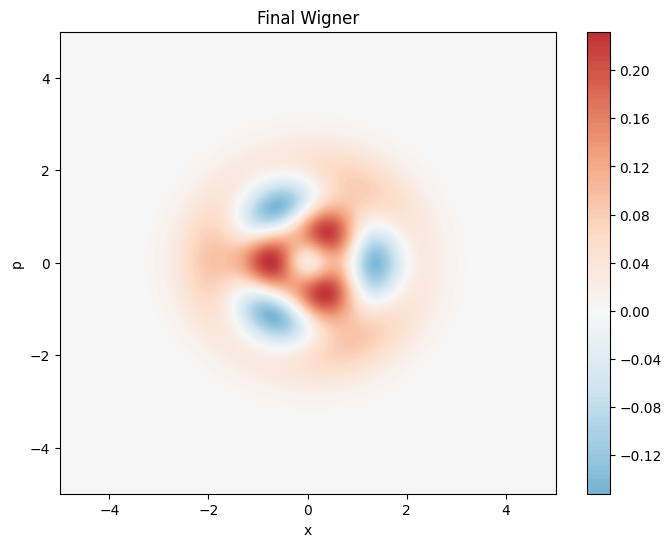

In [30]:
# Phase-space grid
x = np.linspace(-5, 5, 200)
p = np.linspace(-5, 5, 200)
# Compute Wigner function
W = qutip.wigner(rho_cav_final, x, p)
# Plot
fig = plt.figure(figsize=(8, 6))
ax = plt.gca()
contourf = ax.contourf(x, p, W, 100, cmap="RdBu_r",vmin = -1/np.pi, vmax = 1/np.pi)
ax.set(xlabel="x", ylabel="p", title="Final Wigner")
cbar = fig.colorbar(contourf)
fig.savefig("figures_May_2026/Final_Wigner_initial.jpg", bbox_inches="tight", dpi=400)

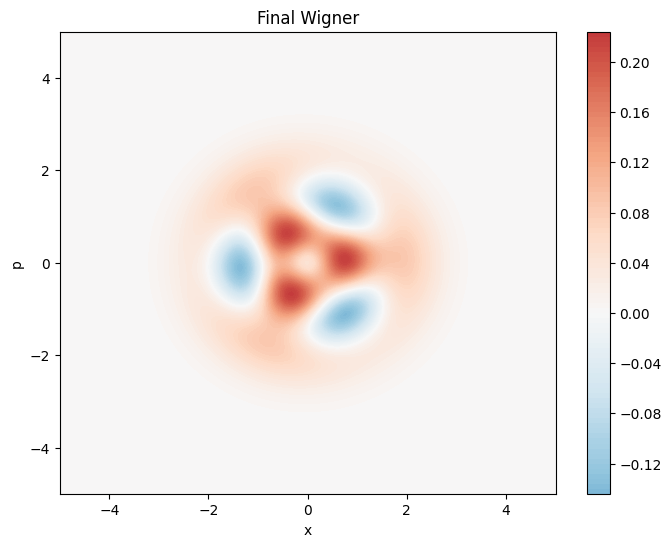

In [36]:
x = np.linspace(-5, 5, 200)
p = np.linspace(-5, 5, 200)
# Compute Wigner function
W = qutip.wigner(rho_cav_final_ramp, x, p)
# Plot
fig = plt.figure(figsize=(8, 6))
ax = plt.gca()
contourf = ax.contourf(x, p, W, 100, cmap="RdBu_r",vmin = -1/np.pi, vmax = 1/np.pi)
ax.set(xlabel="x", ylabel="p", title="Final Wigner")
cbar = fig.colorbar(contourf)
fig.savefig("figures_May_2026/Final_Wigner_ramp.jpg", bbox_inches="tight", dpi=400)

#### Target state

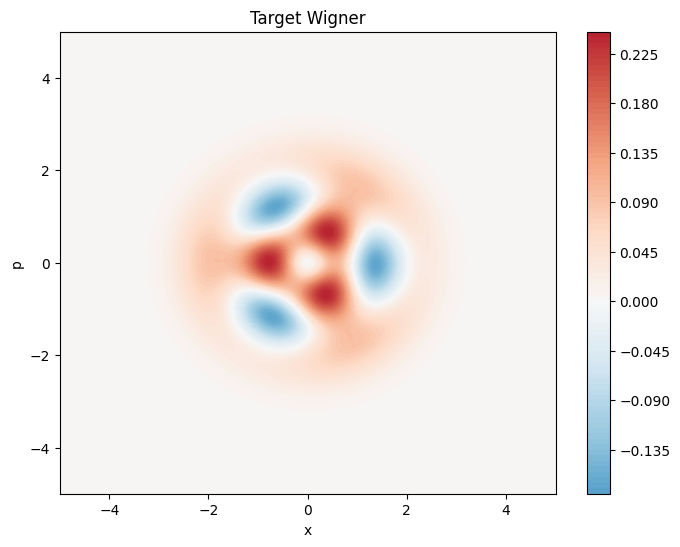

In [ ]:
W = qutip.wigner(rho_target, x, p)
fig = plt.figure(figsize=(8, 6))
ax = plt.gca()
contourf = ax.contourf(x, p, W, 100, cmap="RdBu_r",vmin = -1/np.pi, vmax = 1/np.pi)
ax.set(xlabel="x", ylabel="p", title="Target Wigner")
cbar = fig.colorbar(contourf)
# fig.savefig("figures_May_2026/Target_Wigner.jpg", bbox_inches="tight", dpi=400)